In [ ]:
import pandas as pd
import numpy as np
import sqlalchemy
import seaborn as sns
import requests
import matplotlib.pyplot as plt 
from IPython.display import display
from pathlib import Path
import pandas as pd


THRESHHOLD_MISSING_SAMPLES_PCT = 5

DATASET_DIR = (Path().resolve().parent / "Dataset").resolve()


In [ ]:

merged_path = DATASET_DIR / "merged_imp_csv"
metadata = pd.read_csv(DATASET_DIR / "metadata.csv")

merged_users = {f.stem for f in merged_path.glob("*.csv")}
metadata_users = set(metadata["user"].astype(str))

print("Users in merged:", len(merged_users))
print("Users in metadata:", len(metadata_users))

print("Merged but NOT in metadata:", len(merged_users - metadata_users))
print("Metadata but NOT in merged:", len(metadata_users - merged_users))


In [ ]:
metadata["user"] = metadata["user"].astype(str)

metadata_aligned = metadata[
    metadata["user"].isin(merged_users)
].copy()

print("Aligned metadata shape:", metadata_aligned.shape)

metadata_aligned.to_csv(
    DATASET_DIR / "metadata_aligned.csv",
    index=False
)


In [ ]:
metadata = pd.read_csv(DATASET_DIR / 'metadata_aligned.csv')
print("Columns in metadata file:")
print(metadata.columns.tolist())

metadata.info()
print(len(metadata["cnae"].unique()))
selected_columns = ['user', 'length_years','missing_samples_pct','p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'cnae','contracted_tariff','zip_code', 'municipality']
metadata = metadata[selected_columns]


                     Count  Percentage
missing_samples_pct                   
0-5%                 19709       98.55
5-10%                  123        0.62
10-15%                  46        0.23
15-20%                  23        0.12
20-25%                  22        0.11
25-30%                  12        0.06
30-35%                  12        0.06
35-40%                   9        0.05
40-45%                   8        0.04
45-50%                   7        0.04
50-55%                   4        0.02
55-60%                   5        0.03
60-65%                   2        0.01
65-70%                   7        0.04
70-75%                   2        0.01
75-80%                   1        0.01
80-85%                   0        0.00
85-90%                   0        0.00
90-95%                   4        0.02
95-100%                  2        0.01


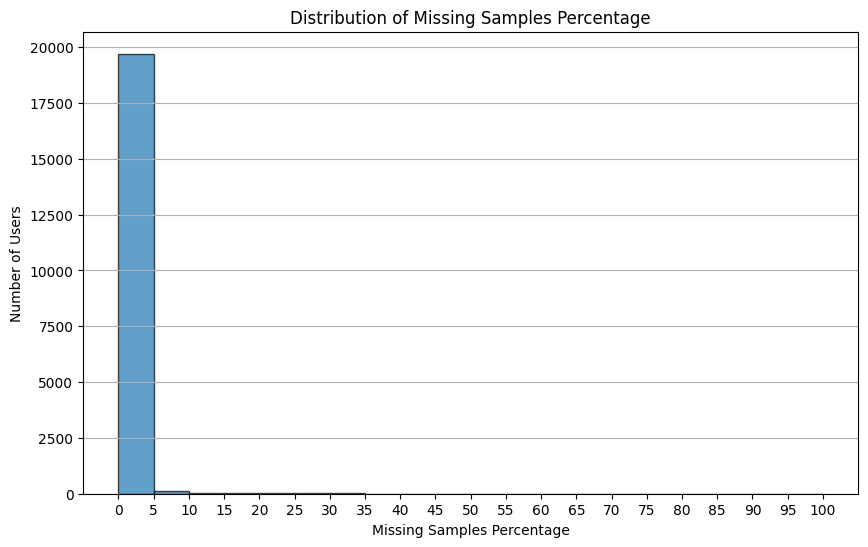

In [6]:
# Bin the 'missing_samples_pct' into 5% intervals
bins = np.arange(0, 105, 5)
labels = [f"{i}-{i+5}%" for i in bins[:-1]]
missing_pct_bin = pd.cut(metadata['missing_samples_pct'], bins=bins, labels=labels, right=False)
# Create a table with counts and percentages for each missing_pct_bin group
bin_counts = missing_pct_bin.value_counts().sort_index()
bin_percentages = (bin_counts / bin_counts.sum() * 100).round(2)
missing_pct_summary = pd.DataFrame({
    'Count': bin_counts,
    'Percentage': bin_percentages
})
print(missing_pct_summary)

# Plot histogram of missing_samples_pct
plt.figure(figsize=(10, 6))
plt.hist(metadata['missing_samples_pct'], bins=bins, edgecolor='k', alpha=0.7)
plt.xlabel('Missing Samples Percentage')
plt.ylabel('Number of Users')
plt.title('Distribution of Missing Samples Percentage')
plt.xticks(bins)
plt.grid(axis='y')
plt.show()


In [7]:
# Filter out users with more than 5% missing samples
metadata = metadata[metadata['missing_samples_pct'] <= THRESHHOLD_MISSING_SAMPLES_PCT]
print(f"Number of users with <= {THRESHHOLD_MISSING_SAMPLES_PCT}% missing samples: {len(metadata)} out of 19998 users")

Number of users with <= 5% missing samples: 19709 out of 19998 users


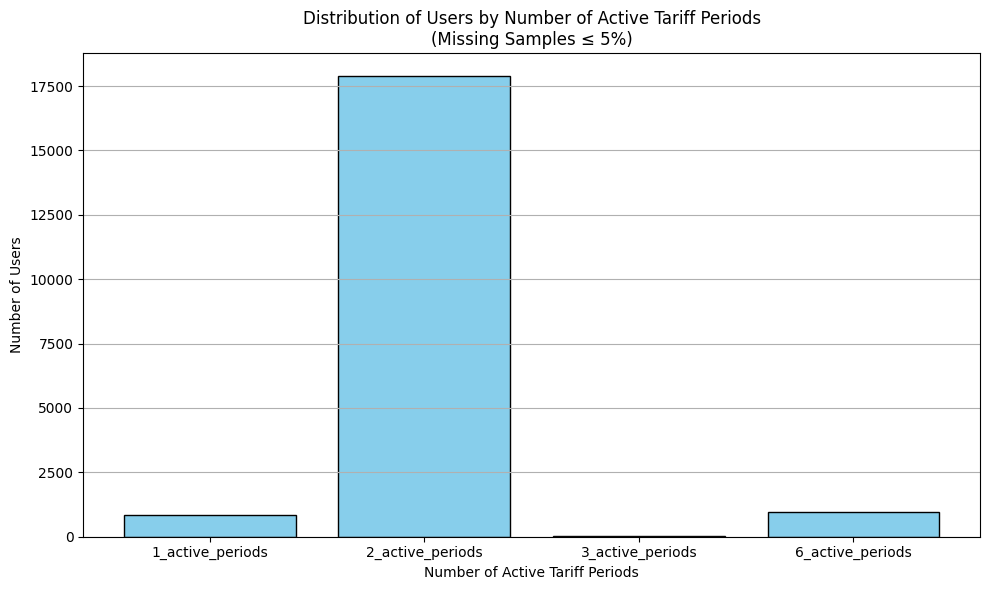

contracted_tariff
1_active_periods      855
2_active_periods    17885
3_active_periods       30
6_active_periods      939
Name: user, dtype: int64


In [8]:
# df_metadata already filtered (e.g., missing_samples_pct <= 5%)

p_cols = ["p1", "p2", "p3", "p4", "p5", "p6"]

# Count active tariff periods per user
metadata["num_active_periods"] = (metadata[p_cols] > 0).sum(axis=1)

# Create group labels
metadata["contracted_tariff"] = metadata["num_active_periods"].apply(
    lambda x: f"{x}_active_periods"
)

# Distribution of users per group
group_counts = (
    metadata
    .groupby("contracted_tariff")["user"]
    .nunique()
    .sort_index()
)
plt.figure(figsize=(10, 6))
plt.bar(group_counts.index, group_counts.values, color='skyblue', edgecolor='k')
plt.xlabel("Number of Active Tariff Periods")
plt.ylabel("Number of Users")
plt.title(f"Distribution of Users by Number of Active Tariff Periods\n(Missing Samples ≤ {THRESHHOLD_MISSING_SAMPLES_PCT}%)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


print(group_counts)


In [9]:
# Remove users with '0_active_periods' and '3_active_periods'
metadata = metadata[~metadata['contracted_tariff'].isin(['0_active_periods', '3_active_periods'])]
print(len(metadata))

19679


\noindent
An analysis of tariff profile distributions revealed that the majority of users (approximately 89\\%) are associated with two active tariff periods. Consequently, this group was selected as the primary focus for subsequent analyses. Users with one or six active tariff periods were retained for comparative evaluation, while groups with zero or three active periods were excluded due to insufficient size or incomplete tariff information.


In [10]:
avg_length_years = metadata['length_years'].mean()
print(f"Average length_years: {avg_length_years:.4f}")

Average length_years: 3.4603


Summary statistics for length_years by number of active periods:
                      count      mean       std       min       25%       50%  \
num_active_periods                                                              
1                     855.0  2.343503  0.835324  1.004791  1.639973  2.299795   
2                   17885.0  3.578697  1.359927  0.999430  2.349076  3.915127   
6                     939.0  2.222354  0.602398  1.007529  1.973990  2.321697   

                         75%       max  
num_active_periods                      
1                   3.036277  5.070728  
2                   5.013005  7.074949  
6                   2.324435  5.013005  


<Figure size 1000x600 with 0 Axes>

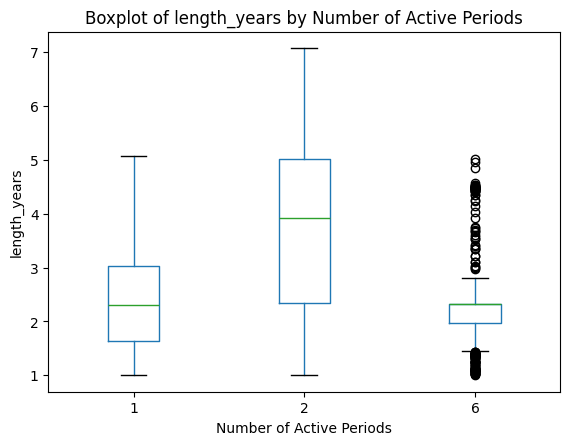

In [11]:

# Include consumption profile columns in the DataFrame
profile_columns = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']
length_years_profiles_df = metadata[['user', 'length_years'] + profile_columns].copy()

# Optionally, add above_avg flag
length_years_profiles_df['above_avg'] = length_years_profiles_df['length_years'] > avg_length_years

# Example: Group by a profile (e.g., number of non-zero periods)
length_years_profiles_df['num_active_periods'] = (length_years_profiles_df[profile_columns] > 0).sum(axis=1)

# Summary statistics by number of active periods
grouped_stats = length_years_profiles_df.groupby('num_active_periods')['length_years'].describe()
print("Summary statistics for length_years by number of active periods:")
print(grouped_stats)


# Boxplot grouped by number of active periods
plt.figure(figsize=(10, 6))
length_years_profiles_df.boxplot(column='length_years', by='num_active_periods', grid=False)
plt.xlabel('Number of Active Periods')
plt.ylabel('length_years')
plt.title('Boxplot of length_years by Number of Active Periods')
plt.suptitle('')
plt.show()


\noindent
Figure~X presents the distribution of time-series duration across tariff profile groups. Users with two active tariff periods exhibit significantly longer monitoring horizons, with a median duration exceeding three years and coverage extending up to seven years. In contrast, users with one or six active periods display shorter and more heterogeneous time-series lengths. Based on both group size and temporal coverage, the two-active-period group was selected as the primary population for subsequent analyses, while the remaining groups were retained for comparative evaluation.



\noindent
Outliers are observed primarily in the six-active-period group, indicating greater heterogeneity in time-series duration within this profile. In contrast, the one- and two-active-period groups exhibit more compact distributions, with no values exceeding the interquartile range thresholds. This further supports the selection of the two-active-period group as the primary focus for analysis.


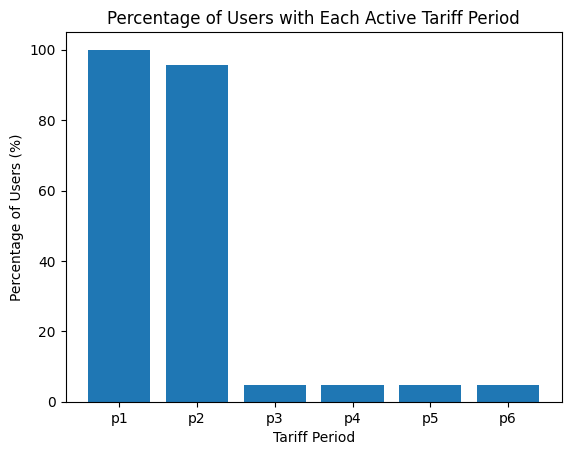

In [12]:

p_cols = ["p1", "p2", "p3", "p4", "p5", "p6"]
p_distribution_pct = (metadata[p_cols] > 0).mean() * 100

plt.figure()
plt.bar(p_distribution_pct.index, p_distribution_pct.values)
plt.xlabel("Tariff Period")
plt.ylabel("Percentage of Users (%)")
plt.title("Percentage of Users with Each Active Tariff Period")
plt.show()

Most common fixture: 1-1-0-0-0-0
Active periods: ['p1', 'p2']
Number of users: 17870


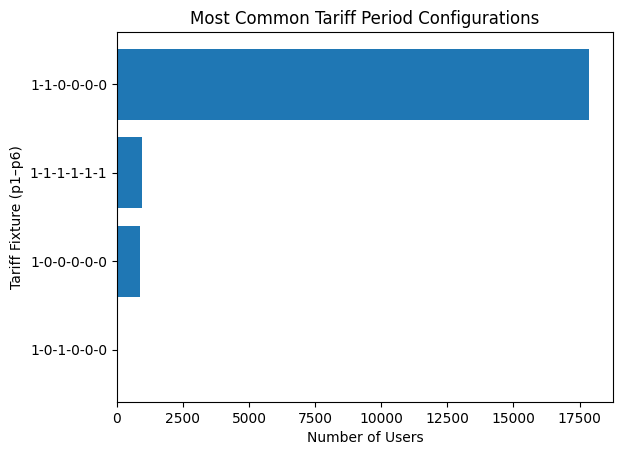

In [13]:

p_cols = ["p1", "p2", "p3", "p4", "p5", "p6"]

# Binary representation of active tariff periods
tariff_binary = (metadata[p_cols] > 0).astype(int)

# Create a fixture label like "0-1-1-0-0-0"
metadata["tariff_fixture"] = tariff_binary.astype(str).agg("-".join, axis=1)
fixture_counts = (
    metadata["tariff_fixture"]
    .value_counts()
)

fixture_counts.head(10)
most_common_fixture = fixture_counts.idxmax()
count = fixture_counts.max()

active_periods = [
    f"p{i+1}"
    for i, v in enumerate(most_common_fixture.split("-"))
    if v == "1"
]

print("Most common fixture:", most_common_fixture)
print("Active periods:", active_periods)
print("Number of users:", count)
import matplotlib.pyplot as plt

top_fixtures = fixture_counts.head(5)

plt.figure()
plt.barh(top_fixtures.index, top_fixtures.values)
plt.xlabel("Number of Users")
plt.ylabel("Tariff Fixture (p1–p6)")
plt.title("Most Common Tariff Period Configurations")
plt.gca().invert_yaxis()
plt.show()


In [14]:


# Count users per fixture
fixture_table = (
    metadata["tariff_fixture"]
    .value_counts()
    .reset_index()
)

fixture_table.columns = ["tariff_fixture", "num_users"]

# Add percentage column
total_users = fixture_table["num_users"].sum()
fixture_table["percentage"] = (
    fixture_table["num_users"] / total_users * 100
).round(2)

fixture_table


,tariff_fixture,num_users,percentage
0,1-1-0-0-0-0,17870,90.81
1,1-1-1-1-1-1,939,4.77
2,1-0-0-0-0-0,855,4.34
3,1-0-1-0-0-0,15,0.08


In [15]:
cnae_sector_map = {
    '01': 'Agriculture, livestock, fishing',
    '02': 'Forestry',
    '03': 'Fishing and aquaculture',
    '05': 'Mining (coal)',
    '06': 'Oil and gas extraction',
    '07': 'Mining (metal ores)',
    '08': 'Other mining',
    '09': 'Mining support services',
    '10': 'Food manufacturing',
    '11': 'Beverage manufacturing',
    '12': 'Tobacco',
    '13': 'Textiles',
    '14': 'Clothing',
    '15': 'Leather and footwear',
    '16': 'Wood and cork',
    '17': 'Paper',
    '18': 'Printing and reproduction',
    '19': 'Refined petroleum',
    '20': 'Chemicals',
    '21': 'Pharmaceuticals',
    '22': 'Rubber and plastics',
    '23': 'Non-metallic minerals',
    '24': 'Metals',
    '25': 'Metal products',
    '26': 'Electronics',
    '27': 'Electrical equipment',
    '28': 'Machinery',
    '29': 'Motor vehicles',
    '30': 'Other transport equipment',
    '31': 'Furniture',
    '32': 'Other manufacturing',
    '33': 'Repair and installation',
    '35': 'Energy (electricity, gas)',
    '36': 'Water supply',
    '37': 'Sewerage',
    '38': 'Waste management',
    '39': 'Environmental remediation',
    '41': 'Construction (buildings)',
    '42': 'Civil engineering',
    '43': 'Specialized construction',
    '45': 'Vehicle trade and repair',
    '46': 'Wholesale trade',
    '47': 'Retail trade',
    '49': 'Land transport',
    '50': 'Water transport',
    '51': 'Air transport',
    '52': 'Warehousing and logistics',
    '53': 'Postal and courier',
    '55': 'Accommodation',
    '56': 'Food and beverage services',
    '58': 'Publishing',
    '59': 'Film, video, TV',
    '60': 'Broadcasting',
    '61': 'Telecommunications',
    '62': 'IT and programming',
    '63': 'Information services',
    '64': 'Financial services',
    '65': 'Insurance',
    '66': 'Financial auxiliary',
    '68': 'Real estate',
    '69': 'Legal and accounting',
    '70': 'Consulting and management',
    '71': 'Architecture and engineering',
    '72': 'R&D',
    '73': 'Advertising',
    '74': 'Other professional services',
    '75': 'Veterinary',
    '77': 'Rental and leasing',
    '78': 'Employment services',
    '79': 'Travel agencies',
    '80': 'Security services',
    '81': 'Cleaning and maintenance',
    '82': 'Office support',
    '84': 'Public administration',
    '85': 'Education',
    '86': 'Healthcare',
    '87': 'Residential care',
    '88': 'Social work',
    '90': 'Creative arts',
    '91': 'Libraries, museums',
    '92': 'Gambling',
    '93': 'Sports and recreation',
    '94': 'Associations',
    '95': 'Repair services',
    '96': 'Personal services',
    '97': 'Domestic employment',
    '98': 'Household production',
    '99': 'Extraterritorial organizations'
}

In [16]:

# Replace bad value
metadata['cnae'] = metadata['cnae'].replace('0nan', np.nan)

# Convert to string BEFORE using .str
metadata['cnae'] = metadata['cnae'].astype('string')

# Remove decimal artifacts if they exist (e.g., 5610.0)
metadata['cnae'] = metadata['cnae'].str.replace('.0', '', regex=False)

# Pad with leading zeros
metadata['cnae'] = metadata['cnae'].str.zfill(4)

# Extract sector (2-digit)
metadata['cnae_2d'] = metadata['cnae'].str[:2]

# Map to sector
metadata['sector'] = metadata['cnae_2d'].map(cnae_sector_map)

# Optional: handle missing mappings
metadata['sector'] = metadata['sector'].fillna('Unknown')

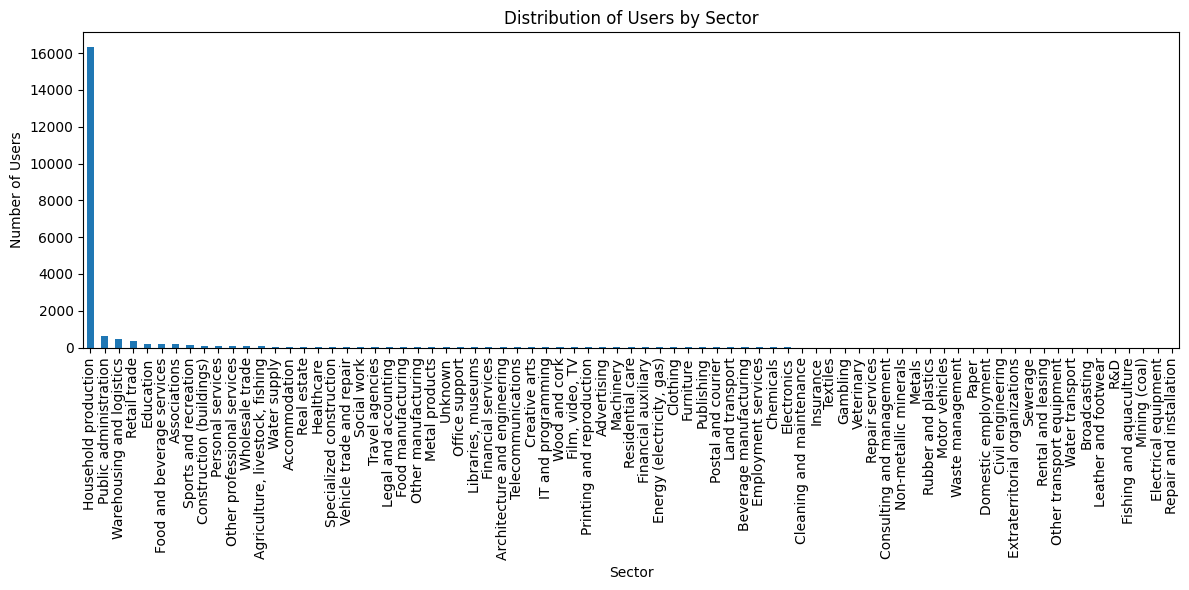

77


,Sector,Number of Users,Percentage
0,Household production,16311,82.89
1,Public administration,612,3.11
2,Warehousing and logistics,481,2.44
3,Retail trade,346,1.76
4,Education,211,1.07
...,...,...,...
72,R&D,1,0.01
73,Fishing and aquaculture,1,0.01
74,Mining (coal),1,0.01
75,Electrical equipment,1,0.01


In [17]:
# Count users by sector
sector_counts = metadata['sector'].value_counts().sort_values(ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 6))
sector_counts.plot(kind='bar')
plt.xlabel('Sector')
plt.ylabel('Number of Users')
plt.title('Distribution of Users by Sector')
plt.tight_layout()
plt.show()

# Display the counts
print(len(sector_counts))
# Create a DataFrame with all sector counts
sector_table = sector_counts.reset_index()
sector_table.columns = ['Sector', 'Number of Users']
# Add percentage column to sector_table
sector_table['Percentage'] = (sector_table['Number of Users'] / sector_table['Number of Users'].sum() * 100).round(2)
sector_table

330


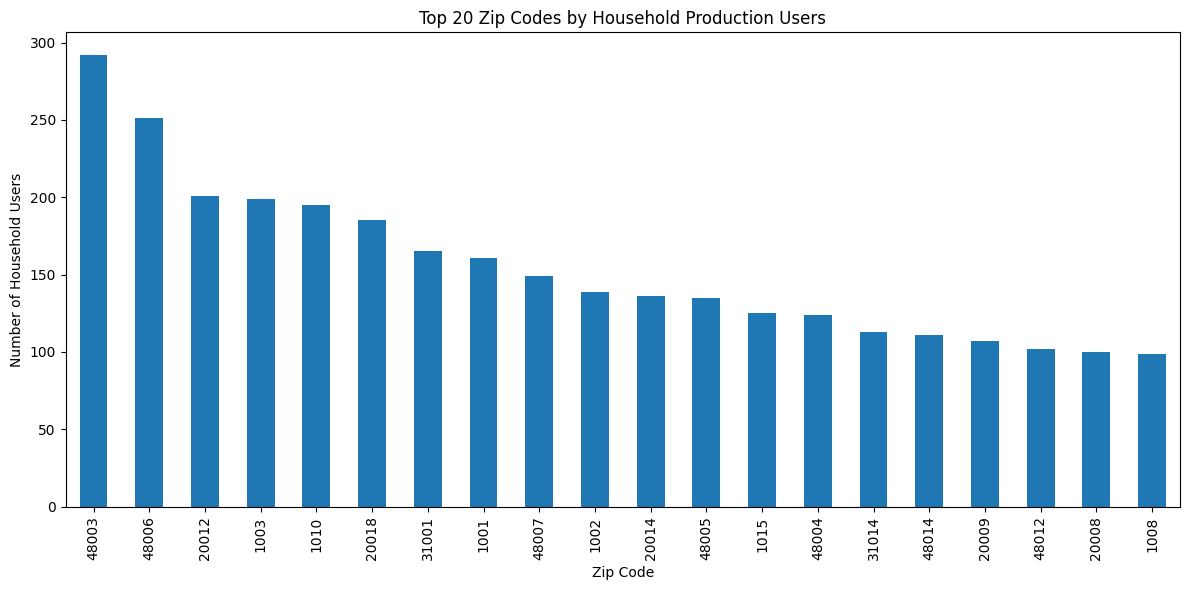

In [18]:
# Filter for 'Household production' sector
household_df = metadata[metadata['sector'] == 'Household production'].copy()

# Drop rows with missing zip_code
household_df = household_df.dropna(subset=['zip_code'])

# Convert zip_code to integer for grouping (if not already)
household_df['zip_code'] = household_df['zip_code'].astype(int)

# Group by zip_code and count users
zip_counts = household_df.groupby('zip_code')['user'].nunique().sort_values(ascending=False)

# Display the top zones
print(len(zip_counts))

# Plot the distribution (top 20 zip codes)
plt.figure(figsize=(12, 6))
zip_counts.head(20).plot(kind='bar')
plt.xlabel('Zip Code')
plt.ylabel('Number of Household Users')
plt.title('Top 20 Zip Codes by Household Production Users')
plt.tight_layout()
plt.show()

In [19]:
num_null_zip = metadata['zip_code'].isnull().sum()
num_nonnull_zip = metadata['zip_code'].notnull().sum()
print(f"Null zip_code: {num_null_zip}")
print(f"Non-null zip_code: {num_nonnull_zip}")
# Show the sector distribution for non-null zip_code entries
non_null_zip_df = metadata[metadata['zip_code'].notnull()]
sector_zip_counts = non_null_zip_df['sector'].value_counts()
print("Sector distribution for users with non-null zip_code:")
print(sector_zip_counts)

# Show sector distribution for users with null zip_code
null_zip_df = metadata[metadata['zip_code'].isnull()]
sector_null_zip_counts = null_zip_df['sector'].value_counts()
print("Sector distribution for users with null zip_code:")
print(sector_null_zip_counts)

Null zip_code: 12418
Non-null zip_code: 7261
Sector distribution for users with non-null zip_code:
sector
Household production               6391
Retail trade                        141
Warehousing and logistics           137
Associations                         64
Education                            58
Food and beverage services           56
Other professional services          40
Construction (buildings)             37
Personal services                    34
Wholesale trade                      28
Public administration                20
Other manufacturing                  18
Legal and accounting                 18
Real estate                          15
Sports and recreation                14
Travel agencies                      13
Vehicle trade and repair             13
Social work                          10
Architecture and engineering         10
Office support                       10
Financial services                   10
Unknown                               9
Printing and r

In [20]:
num_null_municipality = metadata['municipality'].isnull().sum()
print(f"Number of users without a municipality: {num_null_municipality}")

Number of users without a municipality: 12418


In [21]:
metadata['municipality']

0                           NaN
1        Donostia/San Sebastian
2                          Irun
3                           NaN
4                           NaN
                  ...          
19993                       NaN
19994           Vitoria-Gasteiz
19995                       NaN
19996                       NaN
19997                       NaN
Name: municipality, Length: 19679, dtype: object

In [ ]:
metadata.to_csv(DATASET_DIR / 'filtered_metadata.csv', index=False)
print("Filtered metadata saved to", DATASET_DIR / 'filtered_metadata.csv')


distribuição uni e bi variadas dos 2 setores mais populosos 

distribuição uni e bi variadas dos 2 setores mais populosos 

Consumo médio de região vs consumo médio pais 

agrupar por região e depois fazer a média de consumo e fazer uma analise exploratoria dos dados